In [1]:
pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [3]:
stock = "AAPL"

df = yf.download(stock, start="2020-01-01", end="2025-01-01")

print(df.head())

/tmp/ipykernel_14442/837109041.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333862  72.394070  71.091169  71.344039  135480400
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2020-01-06  72.201424  72.239958  70.503561  70.754028  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017838  73.318877  71.565621  71.565621  132079200


In [4]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(1258, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
None
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03
mean     151.377785   152.899565   149.680871   151.223469  9.057103e+07
std       41.851998    41.992362    41.629302    41.795804  5.324438e+07
min       54.163708    55.160705    51.324804    55.059316  2.323470e+07
25%      126.279104   127.397089   124.278532   125.72440

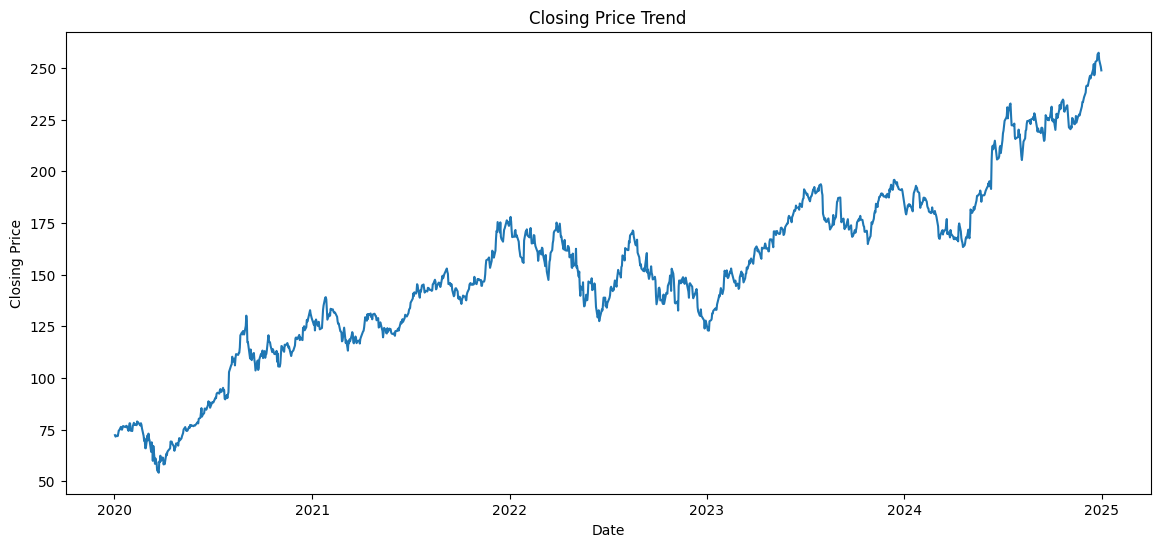

In [5]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title("Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.show()

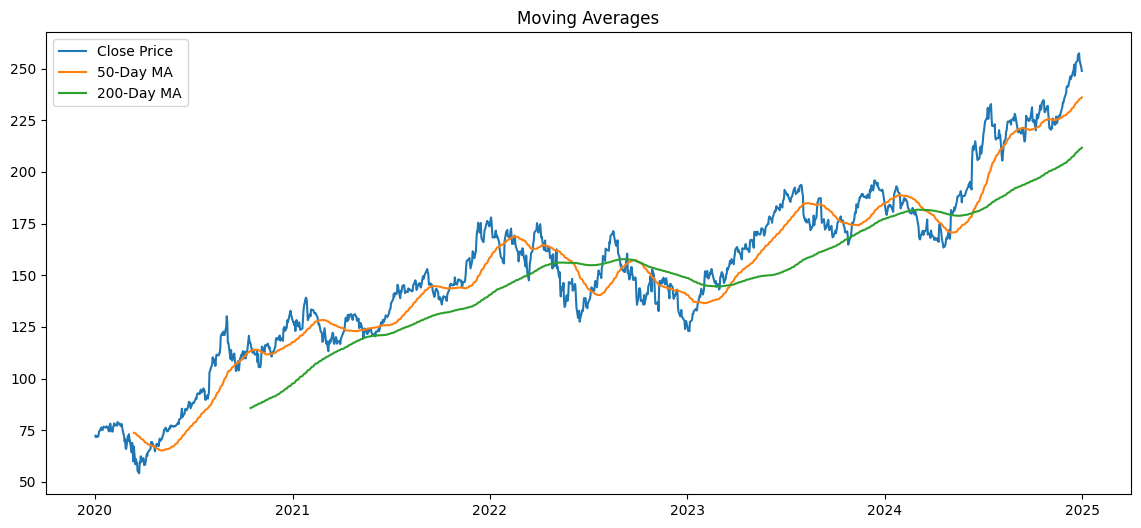

In [6]:
df['MA50'] = df['Close'].rolling(window=50).mean()

df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['MA50'], label='50-Day MA')

plt.plot(df['MA200'], label='200-Day MA')

plt.legend()

plt.title("Moving Averages")

plt.show()

In [7]:
df['Daily Return'] = df['Close'].pct_change()

print(df['Daily Return'].head())

Date
2020-01-02         NaN
2020-01-03   -0.009722
2020-01-06    0.007968
2020-01-07   -0.004703
2020-01-08    0.016086
Name: Daily Return, dtype: float64


In [8]:
volatility = df['Daily Return'].std()

print("Volatility:", volatility)

Volatility: 0.019955664460410815


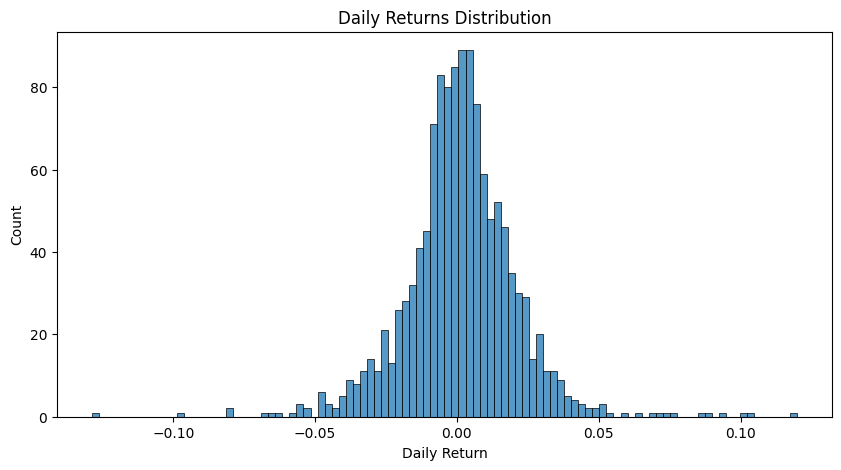

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df['Daily Return'].dropna(), bins=100)

plt.title("Daily Returns Distribution")

plt.show()

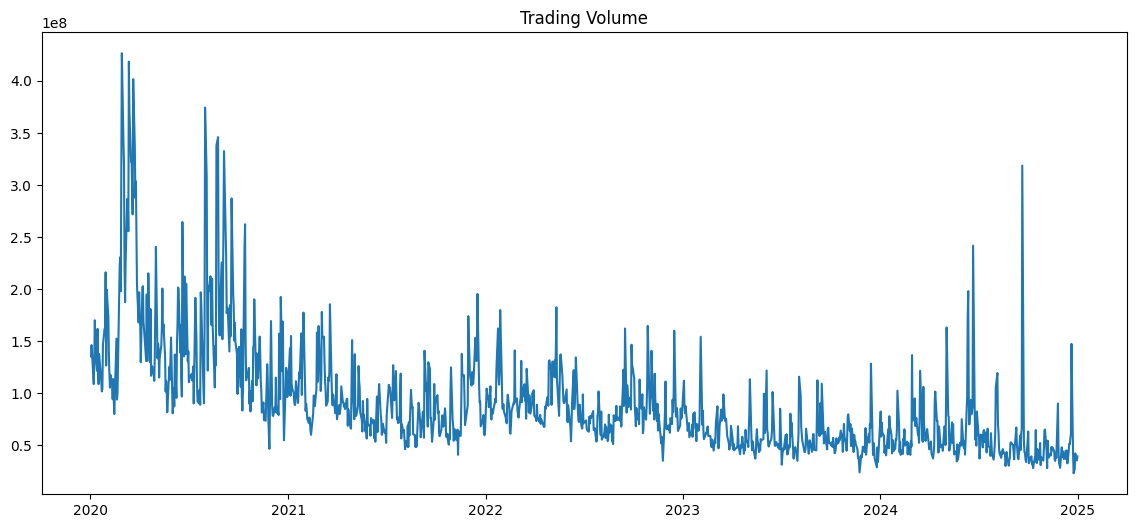

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df['Volume'])

plt.title("Trading Volume")

plt.show()

In [11]:
pip install plotly

In [12]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])

fig.update_layout(
    title='Candlestick Chart',
    xaxis_title='Date',
    yaxis_title='Price'
)

fig.show()

/tmp/ipykernel_14442/1430293903.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  4 of 4 completed


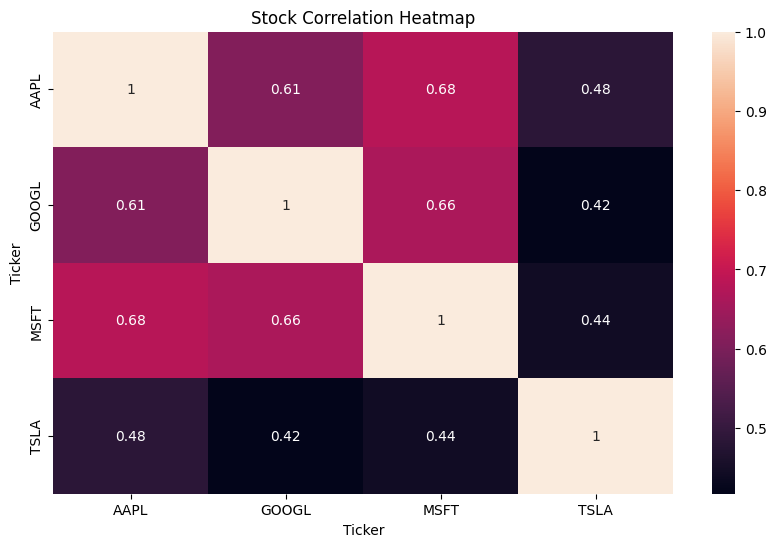

In [13]:
stocks = ['AAPL', 'MSFT', 'TSLA', 'GOOGL']

data = yf.download(stocks, start="2020-01-01")['Close']

returns = data.pct_change()

correlation = returns.corr()

plt.figure(figsize=(10,6))

sns.heatmap(correlation, annot=True)

plt.title("Stock Correlation Heatmap")

plt.show()

In [14]:
portfolio_returns = returns.mean()

portfolio_risk = returns.std()

comparison = pd.DataFrame({
    'Returns': portfolio_returns,
    'Risk': portfolio_risk
})

print(comparison)

         Returns      Risk
Ticker                    
AAPL    0.001075  0.019815
GOOGL   0.001294  0.020401
MSFT    0.000796  0.018718
TSLA    0.002532  0.041161


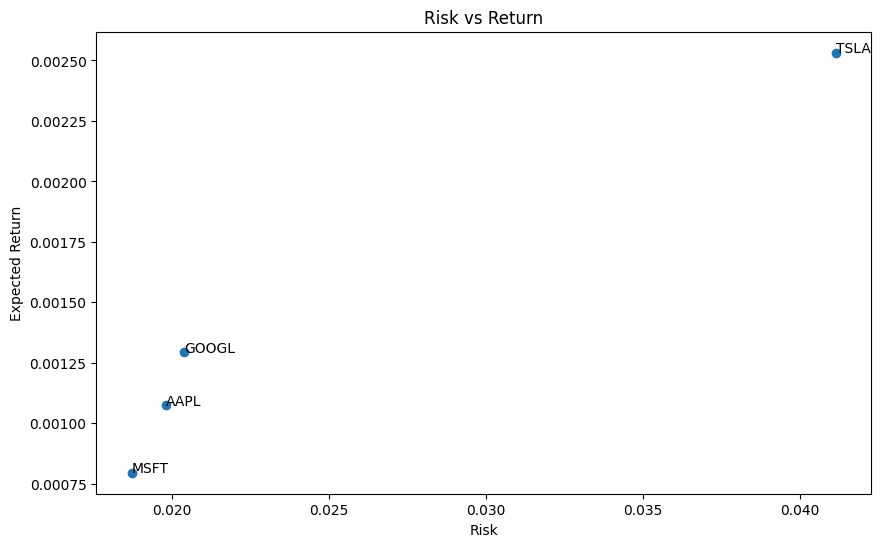

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(portfolio_risk, portfolio_returns)

for i in comparison.index:
    plt.text(portfolio_risk[i], portfolio_returns[i], i)

plt.xlabel("Risk")

plt.ylabel("Expected Return")

plt.title("Risk vs Return")

plt.show()